# Generating a Basic Tone:

The carrier wave, $c(t)$ can be modeled by the equation:
$c(t) = A*sin(2\pi*f + \phi) + O$, where $A$ is the amplitude of the sine wave and $O$ is the offset.

In [1]:
import numpy as np

def carrier_wave(x, frequency = 700, amplitude = 1, phase = 0, offset = 0):
    return (amplitude * np.sin(2 * np.pi * frequency * x + phase) + offset)

duration = 5
sample_rate = 8000

total_samples = 5*8000

x_values = np.linspace(start = 0, stop = 5, num = total_samples)
c_t = carrier_wave(x_values)

An $8 \text{ kHz}$ sample rate seems like enough for generating synthetic data.

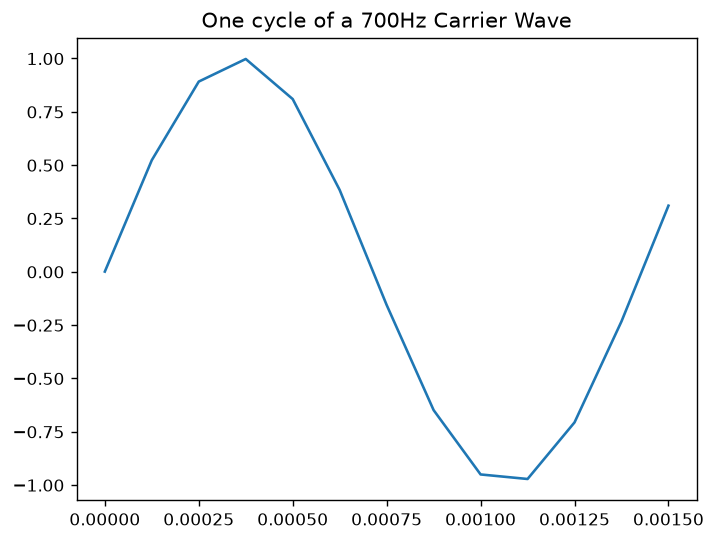

In [2]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots()

ax.plot(x_values[0:13], c_t[0:13])
plt.title("One cycle of a 700Hz Carrier Wave")
plt.style.use("fivethirtyeight")
plt.show()

Basic math here, but it's nice to realize why this models a full cycle:

$700 \text{ Hz} = 700 \frac{\text{cycles}}{ second} = \frac{1 \text{second}}{700 \text{ cycles}}$

The inverse gives $\frac{\text{seconds}}{\text{cycles}}$:

$\frac{1 \text{ seconds}}{700 \text{ cycles}} * \text {sample rate} = \text{target}$

Now, there's enough to try saving this to a .wav so it's playable:

In [3]:
from scipy.io import wavfile

# Convert the data to PCM & int16 for the computer's sound card:
audio_int16 = (c_t * 32767).astype(np.int16)
audio_file = wavfile.write("700hz-5sec.wav", sample_rate, audio_int16)

In [4]:
from IPython.display import Audio, display
display(Audio("700hz-5sec.wav"))

# Generating the Modulation for OOK:

Essentially, we're modeling a CW key here:

## Side-trip: Understanding dit length and PARIS standard

Words per minute (WPM) is the usual way to represent speed of typing or writing, etc. The same's true for CW. However, we need to know the speed at which we tap the key. But, some words are longer than others, so some sort of average had to be established as a baseline.

For reasons that are unclear, the word "PARIS" was chosen.
PARIS in CW Code is represented as:

P: dit-dah-dah-dit

A: dit-dah

R: dit-dah-dit

I: dit-dit

S: dit-dit-dit

Number of dits: 10

number of dah: 4

a dit represents 1 unit, a dah 3 units. Intra-character gaps have 1 silent unit, inter-character gaps have 3 units, word gaps have 7 units.
10 + 4*3 + 4*3 + 9 + 7 = 50

So, the agreed average is then $\frac{50 \text{ units}}{word}$

This gives a formula for dit duration for any given WPM as: $t_d = \frac{60}{50* \text{WPM}} = \frac{1.2}{\text{WPM}}$



# Representing a key-down event as a binary function

In [5]:
cw_alphabet = {
    "a": "10111",
    "b": "111010101",
    "c": "11101011101",
    "d": "1110101",
    "e": "1",
    "f": "101011101",
    "g": "111011101",
    "h": "1010101",
    "i": "101",
    "j": "1011101110111",
    "k": "111010111",
    "l": "101110101",
    "m": "1110111",
    "n": "11101",
    "o": "11101110111",
    "p": "10111011101",
    "q": "1110111010111",
    "r": "1011101",
    "s": "10101",
    "t": "111",
    "u": "1010111",
    "v": "101010111",
    "w": "101110111",
    "x": "11101010111",
    "y": "1110101110111",
    "z": "11101110101"
}


cw_alphabet.get("pi")

In [6]:
def word_to_ook_tau(word):
    cw_code = [0]
    for letter in word.lower():
        mapping = cw_alphabet.get(letter)
        cw_code += list(mapping)
        cw_code += list("000")       # Don't forget the intra-word spacing!
        
    cw_code += list("000")    # nor the inter-word spacing (3 from last letter)!

    return [int(x) for x in cw_code]

In [7]:
key_interval = word_to_ook_tau("PARIS")
print(key_interval)

[0, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 1, 0, 1, 1, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0]


So now `key_interval` is all the intervals we care about, in terms of raw timing units, or "beats" to borrow a music term. But, we ultimately need this sequence in terms of samples.

In [9]:
def ook_sr_convert(key_interval, wpm=10, sample_rate=8000):
    tau = 1.2 / wpm
    samples_per_tau = tau * sample_rate          # keep as float, don't round yet

    # boundary[i] = sample index where unit i begins, computed from absolute
    # elapsed time (i * samples_per_tau), not by repeatedly stepping by a
    # truncated per-unit count
    boundaries = np.round(np.arange(len(key_interval) + 1) * samples_per_tau).astype(int)

    converted = np.zeros(boundaries[-1], dtype=int)
    for i, level in enumerate(key_interval):
        converted[boundaries[i]:boundaries[i + 1]] = level

    return converted.tolist()


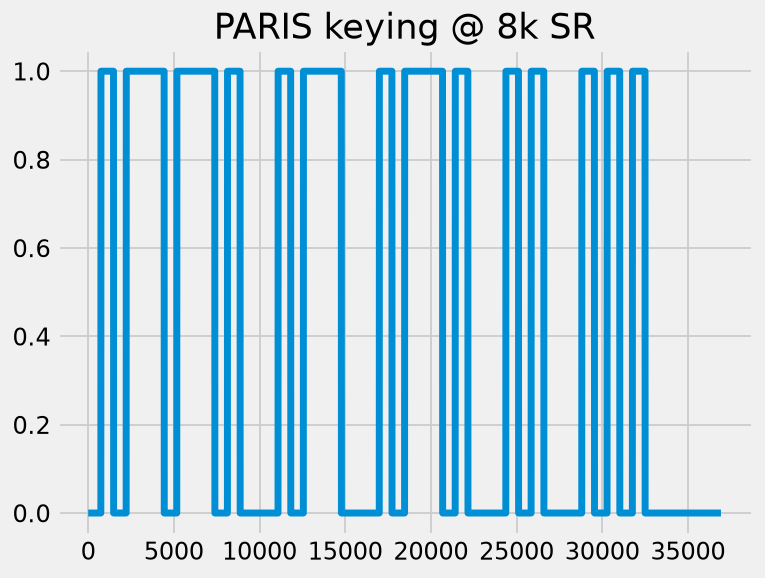

In [10]:
paris_8k = ook_sr_convert(key_interval, wpm=13)
x_values = np.linspace(0, len(paris_8k), len(paris_8k))
m_t = paris_8k


import matplotlib.pyplot as plt

fig, ax = plt.subplots()

ax.plot(x_values, paris_8k)
plt.title("PARIS keying @ 8k SR")
plt.style.use("fivethirtyeight")
plt.show()

# Mixing with the carrier wave

Now, the signal gets mixed. Mixing two sinusoids can be represented as the product of the two frequencies. On-off-keying makes this very intuitive to understand: 

When the key is depressed, $1 * c(t) = c(t)$, else $0$ (silence).

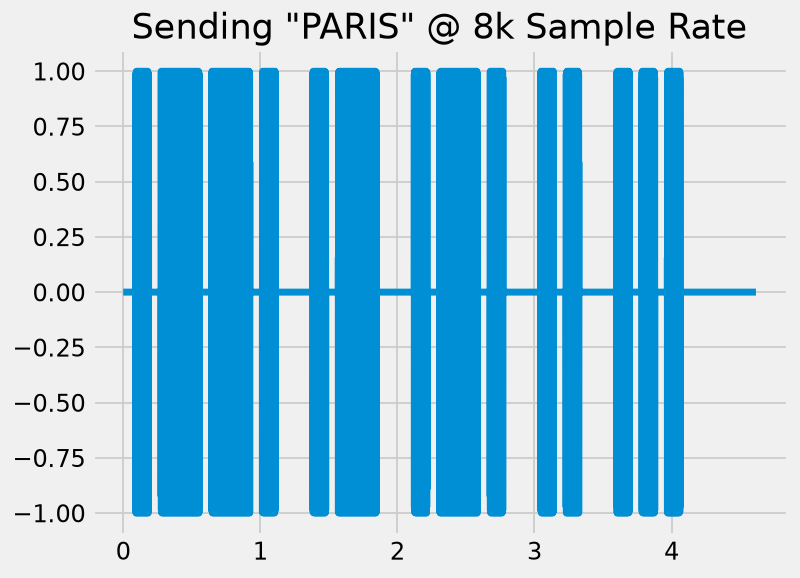

In [11]:
import matplotlib.pyplot as plt

t_values = np.arange(len(paris_8k)) / sample_rate
c_t = carrier_wave(t_values)
mixed_signal = paris_8k * c_t

fig, ax = plt.subplots()

ax.plot(t_values, mixed_signal)
plt.title("Sending \"PARIS\" @ 8k Sample Rate")
plt.style.use("fivethirtyeight")
plt.show()

In [12]:
audio_int16 = (mixed_signal * 32767).astype(np.int16)
audio_file = wavfile.write("PARIS-700hz-mixed.wav", sample_rate, audio_int16)

# Visualizing key clicks: alignment vs. misalignment

We established that at `wpm=10`, `700 Hz * 0.12 s = 84` (an integer) — so every key transition lands exactly on a carrier zero-crossing, and there's no discontinuity to click. At `wpm=13`, the unit duration no longer divides evenly into carrier cycles, so transitions land mid-waveform.

Two ways to see this directly:

1. **Zoom in on a transition in the time domain** — plot a small window of samples straddling the first key-down/key-up edge. The aligned case (`wpm=10`) should show the waveform smoothly crossing zero right at the edge; the misaligned case (`wpm=13`) should show a visible jump.
2. **Look at the spectrum** — a clean, zero-crossing-aligned OOK signal only has the sidebands inherent to the rectangular keying envelope itself (a sinc-shaped skirt around 700 Hz, set by the dit duration). A misaligned transition adds an *extra* instantaneous discontinuity on top of that, which injects broadband energy — showing up as a raised noise floor / wider skirt in the FFT. That's the spectral signature of a "key click."

In [13]:
def build_mixed(wpm):
    paris = np.array(ook_sr_convert(key_interval, wpm=wpm))
    t = np.arange(len(paris)) / sample_rate
    c = carrier_wave(t)
    mixed = paris * c
    return paris, t, c, mixed

paris_10, t_10, c_10, mixed_10 = build_mixed(10)   # aligned: 700*0.12 = 84 cycles/unit
paris_13, t_13, c_13, mixed_13 = build_mixed(13)   # misaligned: 700*(1.2/13) ~= 64.6 cycles/unit

def first_transition(paris):
    diffs = np.diff(paris)
    idx = np.argmax(diffs != 0)   # first sample index where the key changes state
    return idx + 1                # sample where the new state actually begins

trans_10 = first_transition(paris_10)
trans_13 = first_transition(paris_13)
print(f"WPM=10 first transition at sample {trans_10}")
print(f"WPM=13 first transition at sample {trans_13}")

WPM=10 first transition at sample 960
WPM=13 first transition at sample 738


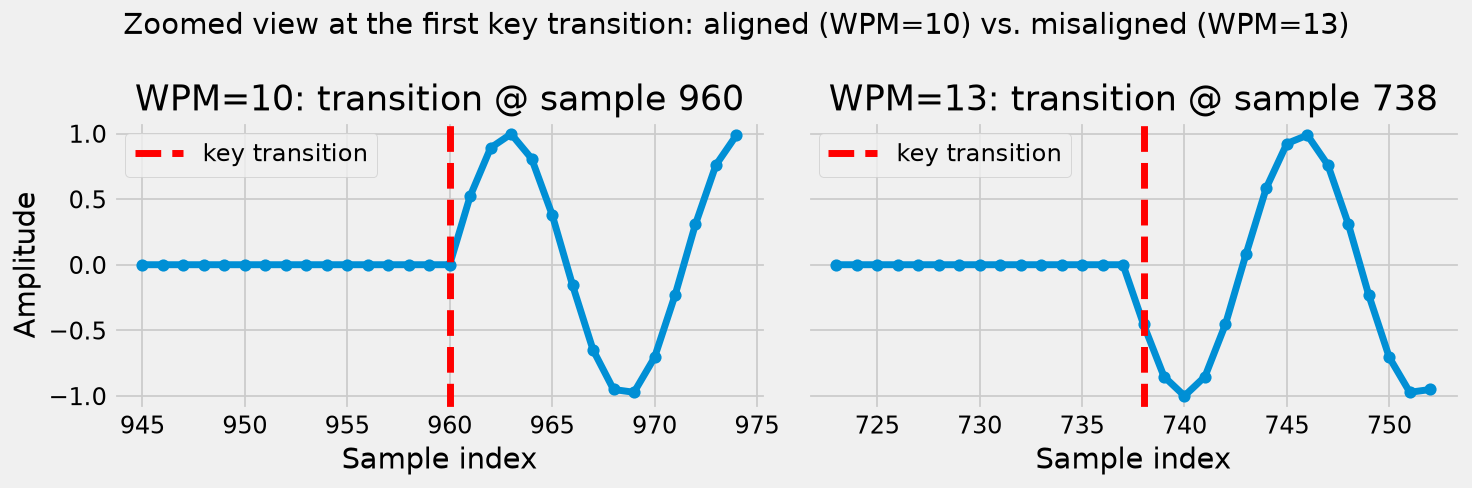

In [14]:
window = 15

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

for ax, mixed, trans, wpm in zip(axes, [mixed_10, mixed_13], [trans_10, trans_13], [10, 13]):
    lo, hi = trans - window, trans + window
    idx = np.arange(lo, hi)
    ax.plot(idx, mixed[lo:hi], marker="o")
    ax.axvline(trans, color="red", linestyle="--", label="key transition")
    ax.set_title(f"WPM={wpm}: transition @ sample {trans}")
    ax.set_xlabel("Sample index")
    ax.legend()

axes[0].set_ylabel("Amplitude")
plt.suptitle('Zoomed view at the first key transition: aligned (WPM=10) vs. misaligned (WPM=13)')
plt.tight_layout()
plt.show()

## Confirming it in the frequency domain

The time-domain zoom shows *where* a discontinuity happens. The FFT shows what it costs you spectrally: any abrupt, non-zero-crossing edge injects broadband energy that a receiver's IF filter would hear as an audible "tick" on adjacent channels. Compare the spectral skirts around 700 Hz for both cases.

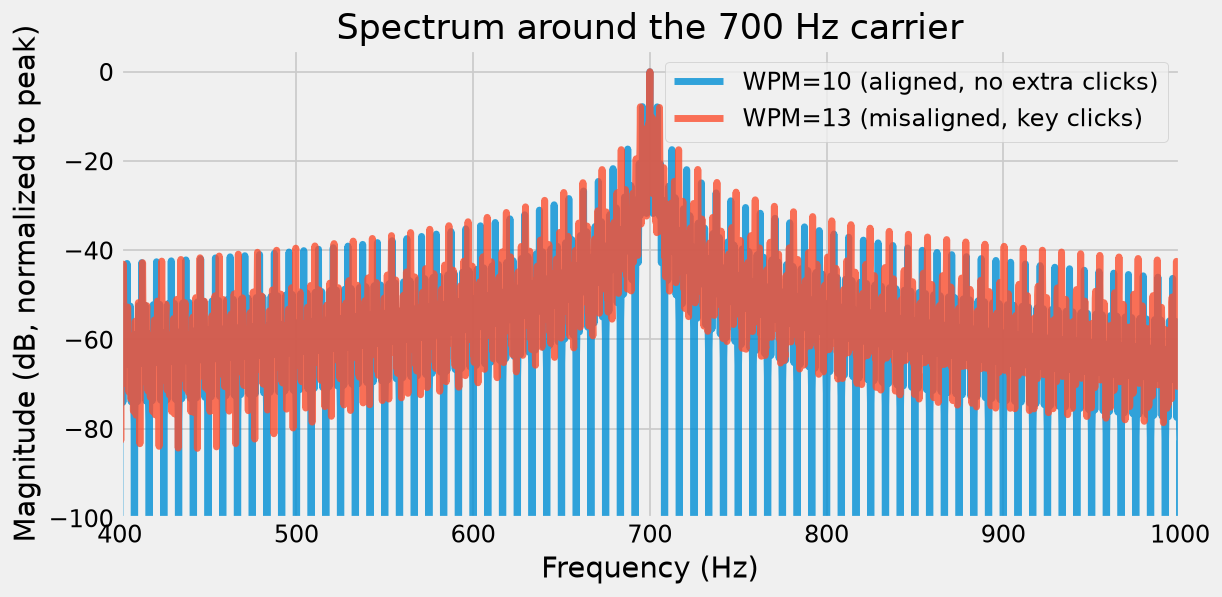

In [15]:
def spectrum_db(signal, sample_rate):
    n = len(signal)
    freqs = np.fft.rfftfreq(n, d=1 / sample_rate)
    mag = np.abs(np.fft.rfft(signal))
    mag_db = 20 * np.log10(mag / mag.max() + 1e-12)   # normalize to 0 dB peak
    return freqs, mag_db

f_10, db_10 = spectrum_db(mixed_10, sample_rate)
f_13, db_13 = spectrum_db(mixed_13, sample_rate)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(f_10, db_10, label="WPM=10 (aligned, no extra clicks)", alpha=0.8)
ax.plot(f_13, db_13, label="WPM=13 (misaligned, key clicks)", alpha=0.8)
ax.set_xlim(400, 1000)
ax.set_ylim(-100, 5)
ax.set_xlabel("Frequency (Hz)")
ax.set_ylabel("Magnitude (dB, normalized to peak)")
ax.set_title("Spectrum around the 700 Hz carrier")
ax.legend()
plt.tight_layout()
plt.show()

# Fixing it: a simple low-pass filter

The simplest low-pass filter to reason about is a **one-pole IIR filter** — the digital equivalent of a basic analog RC low-pass circuit. It's exactly the kind of filter real CW transmitters use to shape key clicks, which makes it a nice one to learn first.

The idea: each output sample is a blend of "how much of the new input to let in" vs. "how much of the last output to keep":

$$y[n] = \alpha \cdot x[n] + (1-\alpha) \cdot y[n-1]$$

- $\alpha$ close to `1`: barely any smoothing — the output tracks the input almost instantly (high cutoff frequency).
- $\alpha$ close to `0`: heavy smoothing — the output only creeps toward the input over many samples (low cutoff frequency), which is exactly what "smears" our instantaneous key clicks into a smooth ramp instead of a jump.

This is a **recursive (IIR)** filter — unlike a moving average, it never has to "remember" a whole window of past samples, just the single previous output. That recursion is *why* it behaves like a charging/discharging RC circuit: `y[n-1]` plays the role of the capacitor's stored voltage.

To pick $\alpha$ from a cutoff frequency $f_c$ (in Hz), we use the standard discretized-RC relationship:

$$RC = \frac{1}{2\pi f_c}, \qquad \alpha = \frac{\Delta t}{RC + \Delta t}, \qquad \Delta t = \frac{1}{\text{sample rate}}$$

We want $f_c$ **above** our 700 Hz carrier (so the tone itself passes through mostly untouched) but **low enough** to round off the sharp edges in `m(t)` that cause the clicks. `fc = 1000 Hz` is a reasonable starting point — try lowering it further and see how much more the clicks get smoothed at the cost of also softening the carrier's own amplitude a little.

In [16]:
def one_pole_lowpass(signal, alpha):
    """A one-pole IIR low-pass filter: y[n] = alpha*x[n] + (1-alpha)*y[n-1].

    Each output sample is a weighted blend of the current input and the
    *previous output* -- so a sudden jump in the input only shows up
    gradually in the output, over several samples, instead of instantly.
    """
    y = np.zeros_like(signal, dtype=float)
    y[0] = signal[0]
    for n in range(1, len(signal)):
        y[n] = alpha * signal[n] + (1 - alpha) * y[n - 1]
    return y

fc = 1000                          # cutoff frequency in Hz (above the 700 Hz carrier)
RC = 1 / (2 * np.pi * fc)
dt = 1 / sample_rate
alpha = dt / (RC + dt)
print(f"cutoff = {fc} Hz  ->  alpha = {alpha:.4f}  (RC time constant = {RC*1000:.2f} ms)")

filtered_13 = one_pole_lowpass(mixed_13, alpha)

cutoff = 1000 Hz  ->  alpha = 0.4399  (RC time constant = 0.16 ms)


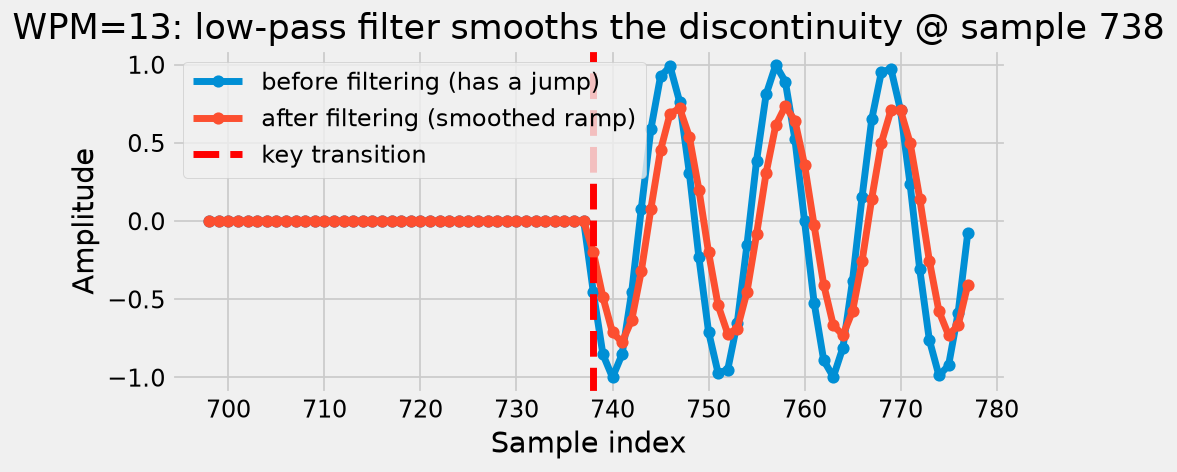

In [17]:
window = 40

fig, ax = plt.subplots(figsize=(8, 4))
lo, hi = trans_13 - window, trans_13 + window
idx = np.arange(lo, hi)
ax.plot(idx, mixed_13[lo:hi], marker="o", label="before filtering (has a jump)")
ax.plot(idx, filtered_13[lo:hi], marker="o", label="after filtering (smoothed ramp)")
ax.axvline(trans_13, color="red", linestyle="--", label="key transition")
ax.set_xlabel("Sample index")
ax.set_ylabel("Amplitude")
ax.set_title(f"WPM=13: low-pass filter smooths the discontinuity @ sample {trans_13}")
ax.legend()
plt.tight_layout()
plt.show()

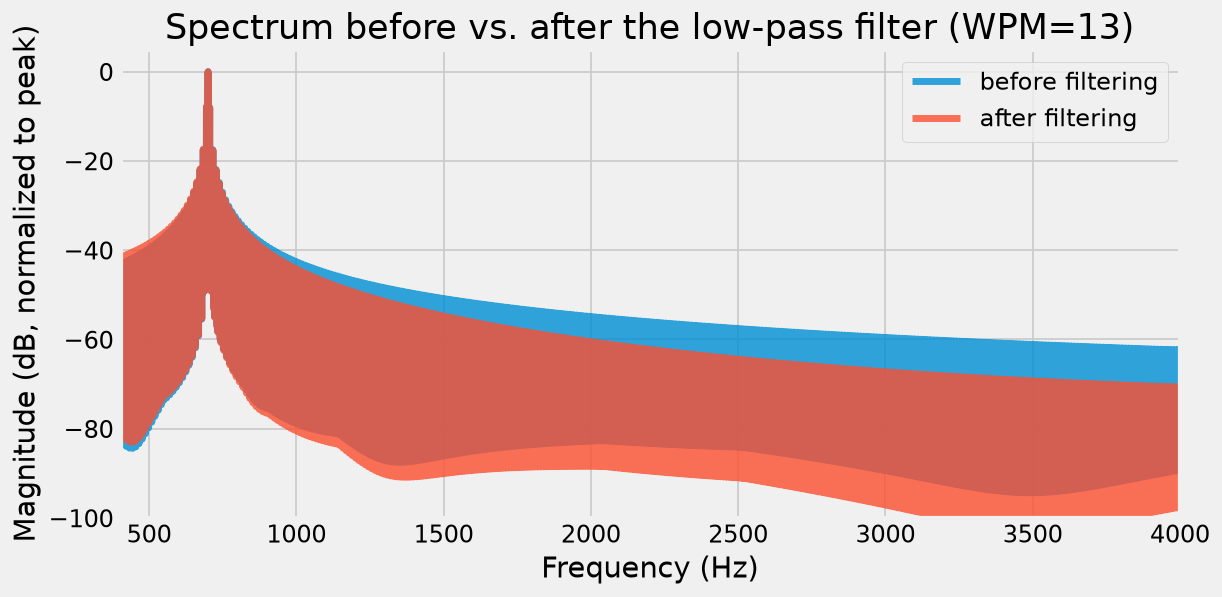

750-850 Hz: before= -53.3 dB, after= -53.9 dB
1500-2500 Hz: before= -71.9 dB, after= -77.5 dB
3000-3999 Hz: before= -75.4 dB, after= -83.5 dB


In [18]:
f_before, db_before = spectrum_db(mixed_13, sample_rate)
f_after, db_after = spectrum_db(filtered_13, sample_rate)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(f_before, db_before, label="before filtering", alpha=0.8)
ax.plot(f_after, db_after, label="after filtering", alpha=0.8)
ax.set_xlim(400, 4000)
ax.set_ylim(-100, 5)
ax.set_xlabel("Frequency (Hz)")
ax.set_ylabel("Magnitude (dB, normalized to peak)")
ax.set_title("Spectrum before vs. after the low-pass filter (WPM=13)")
ax.legend()
plt.tight_layout()
plt.show()

# The carrier itself (near 700 Hz) is barely touched, but the broadband
# splatter from the key clicks -- most visible a couple kHz away from the
# carrier -- drops noticeably once it's been through the filter.
for lo, hi in [(750, 850), (1500, 2500), (3000, 3999)]:
    mask = (f_before > lo) & (f_before < hi)
    print(f"{lo}-{hi} Hz: before={db_before[mask].mean():6.1f} dB, "
          f"after={db_after[mask].mean():6.1f} dB")

In [19]:
# Clip defensively before quantizing -- the filter shouldn't push us outside
# [-1, 1], but it's cheap insurance against int16 wraparound artifacts.
filtered_clipped = np.clip(filtered_13, -1.0, 1.0)
audio_int16_filtered = (filtered_clipped * 32767).astype(np.int16)
wavfile.write("PARIS-700hz-mixed_filtered.wav", sample_rate, audio_int16_filtered)

display(Audio("PARIS-700hz-mixed_filtered.wav"))